<a href="https://colab.research.google.com/github/SURUSAIKEERTHI/DSA0403/blob/main/Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (20640, 9)

First 5 Records:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Dataset after preprocessing: (20640, 9)

Descriptive Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
cou

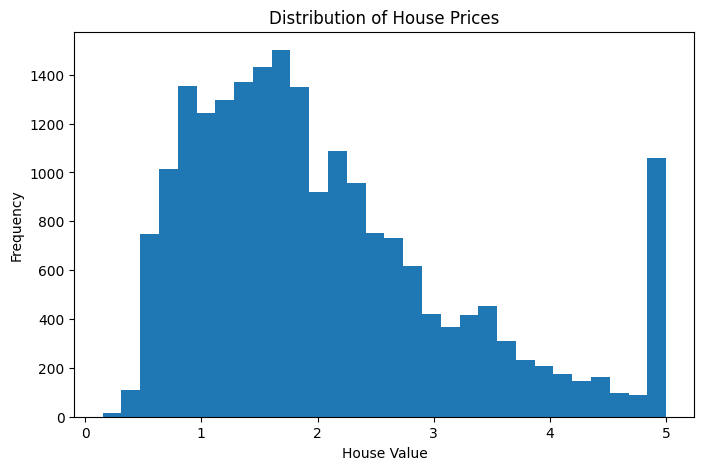


MODEL PERFORMANCE COMPARISON
               Model    MAE    MSE   RMSE     R2
   Linear Regression 0.5332 0.5559 0.7456 0.5758
      kNN Regression 0.4462 0.4324 0.6576 0.6700
Decision Tree / CART 0.4332 0.4155 0.6446 0.6829

Best Model: Decision Tree / CART
Lowest RMSE: 0.6446
R2 Score: 0.6829


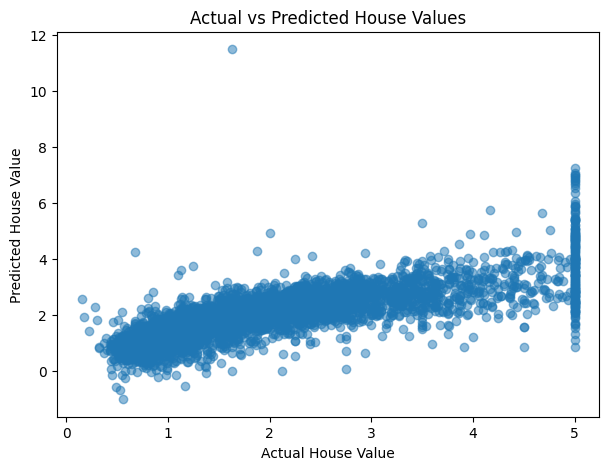

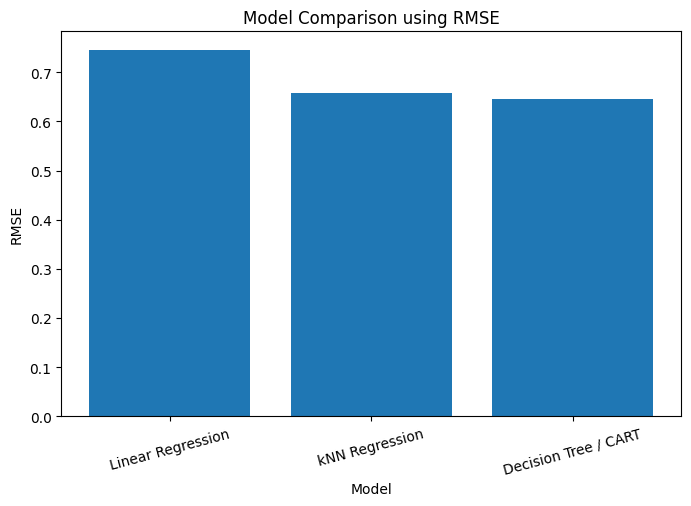

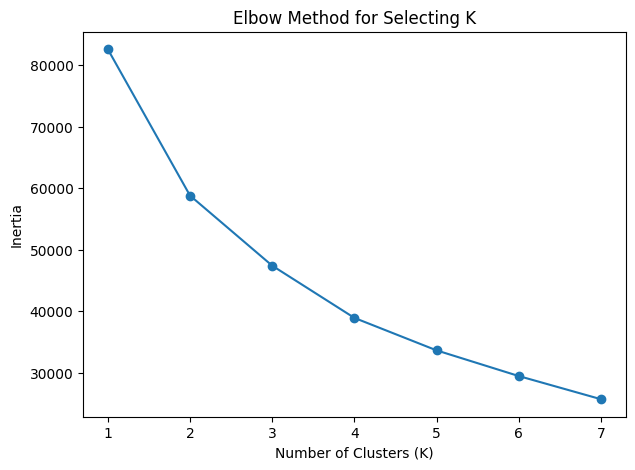


PROPERTY CLUSTERS
   MedInc  HouseAge  AveRooms  MedHouseVal  Cluster
0  8.3252      41.0  6.984127        4.526        1
1  8.3014      21.0  6.238137        3.585        1
2  7.2574      52.0  8.288136        3.521        1
3  5.6431      52.0  5.817352        3.413        1
4  3.8462      52.0  6.281853        3.422        0
5  4.0368      52.0  4.761658        2.697        0
6  3.6591      52.0  4.931907        2.992        0
7  3.1200      52.0  4.797527        2.414        0
8  2.0804      42.0  4.294118        2.267        0
9  3.6912      52.0  4.970588        2.611        0

Cluster Summary:
         MedInc  HouseAge  AveRooms  MedHouseVal
Cluster                                         
0         3.026    38.676     4.730        1.718
1         6.496    28.312     6.964        3.760
2         3.432    17.419     5.405        1.566


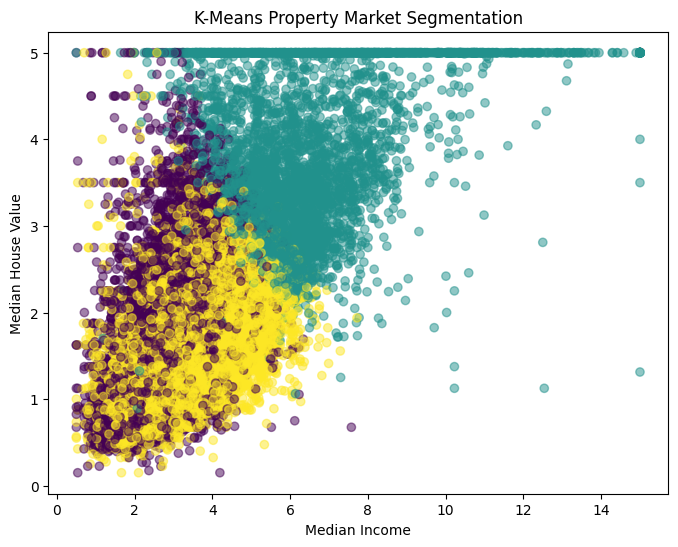


ANALYSIS COMPLETED
Number of records: 20640
Number of clusters: 3
Best prediction model: Decision Tree / CART

Techniques Used:
1. Data Preprocessing
2. Exploratory Data Analysis
3. Descriptive Statistics
4. Confidence Interval
5. Linear Regression
6. kNN Regression
7. Decision Tree / CART
8. Model Evaluation
9. K-Means Clustering
10. Visualization


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats
data = fetch_california_housing(as_frame=True)
df = data.frame
print("Dataset Shape:", df.shape)
print("\nFirst 5 Records:")
print(df.head())
print("\nMissing Values:")
print(df.isnull().sum())
df = df.drop_duplicates()
print("\nDataset after preprocessing:", df.shape)
print("\nDescriptive Statistics:")
print(df.describe())
print("\nMean House Value:",
      round(df["MedHouseVal"].mean(), 3))
print("Variance:",
      round(df["MedHouseVal"].var(), 3))
print("\nCorrelation with House Value:")
print(df.corr()["MedHouseVal"].sort_values(ascending=False))
mean = df["MedHouseVal"].mean()
std = df["MedHouseVal"].std()
n = len(df)
confidence = 0.95

t_value = stats.t.ppf(
    (1 + confidence) / 2,
    n - 1
)
margin = t_value * std / np.sqrt(n)

lower = mean - margin
upper = mean + margin

print("\n95% Confidence Interval:")
print("Lower:", round(lower, 3))
print("Upper:", round(upper, 3))

plt.figure(figsize=(8, 5))

plt.hist(df["MedHouseVal"], bins=30)

plt.xlabel("House Value")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")

plt.show()


X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)
knn_model = KNeighborsRegressor(
    n_neighbors=5
)

knn_model.fit(
    X_train_scaled,
    y_train
)

knn_pred = knn_model.predict(X_test_scaled)

tree_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
def evaluate_model(name, actual, predicted):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    mse = mean_squared_error(
        actual,
        predicted
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        actual,
        predicted
    )

    return [
        name,
        mae,
        mse,
        rmse,
        r2
    ]

results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_pred
    )
)

results.append(
    evaluate_model(
        "kNN Regression",
        y_test,
        knn_pred
    )
)

results.append(
    evaluate_model(
        "Decision Tree / CART",
        y_test,
        tree_pred
    )
)

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2"
    ]
)

print("\n======================================")
print("MODEL PERFORMANCE COMPARISON")
print("======================================")

print(
    results_df.round(4).to_string(
        index=False
    )
)
best_model = results_df.loc[
    results_df["RMSE"].idxmin()
]

print("\nBest Model:",
      best_model["Model"])

print("Lowest RMSE:",
      round(best_model["RMSE"], 4))

print("R2 Score:",
      round(best_model["R2"], 4))
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    linear_pred,
    alpha=0.5
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")

plt.title(
    "Actual vs Predicted House Values"
)

plt.show()

plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")

plt.title(
    "Model Comparison using RMSE"
)

plt.xticks(rotation=15)

plt.show()
cluster_data = df[
    [
        "MedInc",
        "HouseAge",
        "AveRooms",
        "MedHouseVal"
    ]
]

cluster_scaler = StandardScaler()

cluster_scaled = cluster_scaler.fit_transform(
    cluster_data
)

inertia = []

for k in range(1, 8):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(cluster_scaled)

    # Correct attribute: inertia_
    inertia.append(model.inertia_)


plt.figure(figsize=(7, 5))

plt.plot(
    range(1, 8),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.title(
    "Elbow Method for Selecting K"
)

plt.show()
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(
    cluster_scaled
)

print("\n======================================")
print("PROPERTY CLUSTERS")
print("======================================")

print(
    df[
        [
            "MedInc",
            "HouseAge",
            "AveRooms",
            "MedHouseVal",
            "Cluster"
        ]
    ].head(10)
)

print("\nCluster Summary:")

print(
    df.groupby("Cluster")[
        [
            "MedInc",
            "HouseAge",
            "AveRooms",
            "MedHouseVal"
        ]
    ].mean().round(3)
)

plt.figure(figsize=(8, 6))

plt.scatter(
    df["MedInc"],
    df["MedHouseVal"],
    c=df["Cluster"],
    alpha=0.5
)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")

plt.title(
    "K-Means Property Market Segmentation"
)

plt.show()

print("\n======================================")
print("ANALYSIS COMPLETED")
print("======================================")

print(
    "Number of records:",
    len(df)
)

print(
    "Number of clusters:",
    3
)

print(
    "Best prediction model:",
    best_model["Model"]
)

print("\nTechniques Used:")
print("1. Data Preprocessing")
print("2. Exploratory Data Analysis")
print("3. Descriptive Statistics")
print("4. Confidence Interval")
print("5. Linear Regression")
print("6. kNN Regression")
print("7. Decision Tree / CART")
print("8. Model Evaluation")
print("9. K-Means Clustering")
print("10. Visualization")